<a href="https://colab.research.google.com/github/cybermad7373/AIML-Learning/blob/master/01_pytorch_fundamentals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Pytorch Workflow

- Data Prep & Loading
- Build Model
- Fittingmodel to data (training)
- Making predictions and Evaluating thr model (inference)
- Saving and loading model
-- putting all thogether

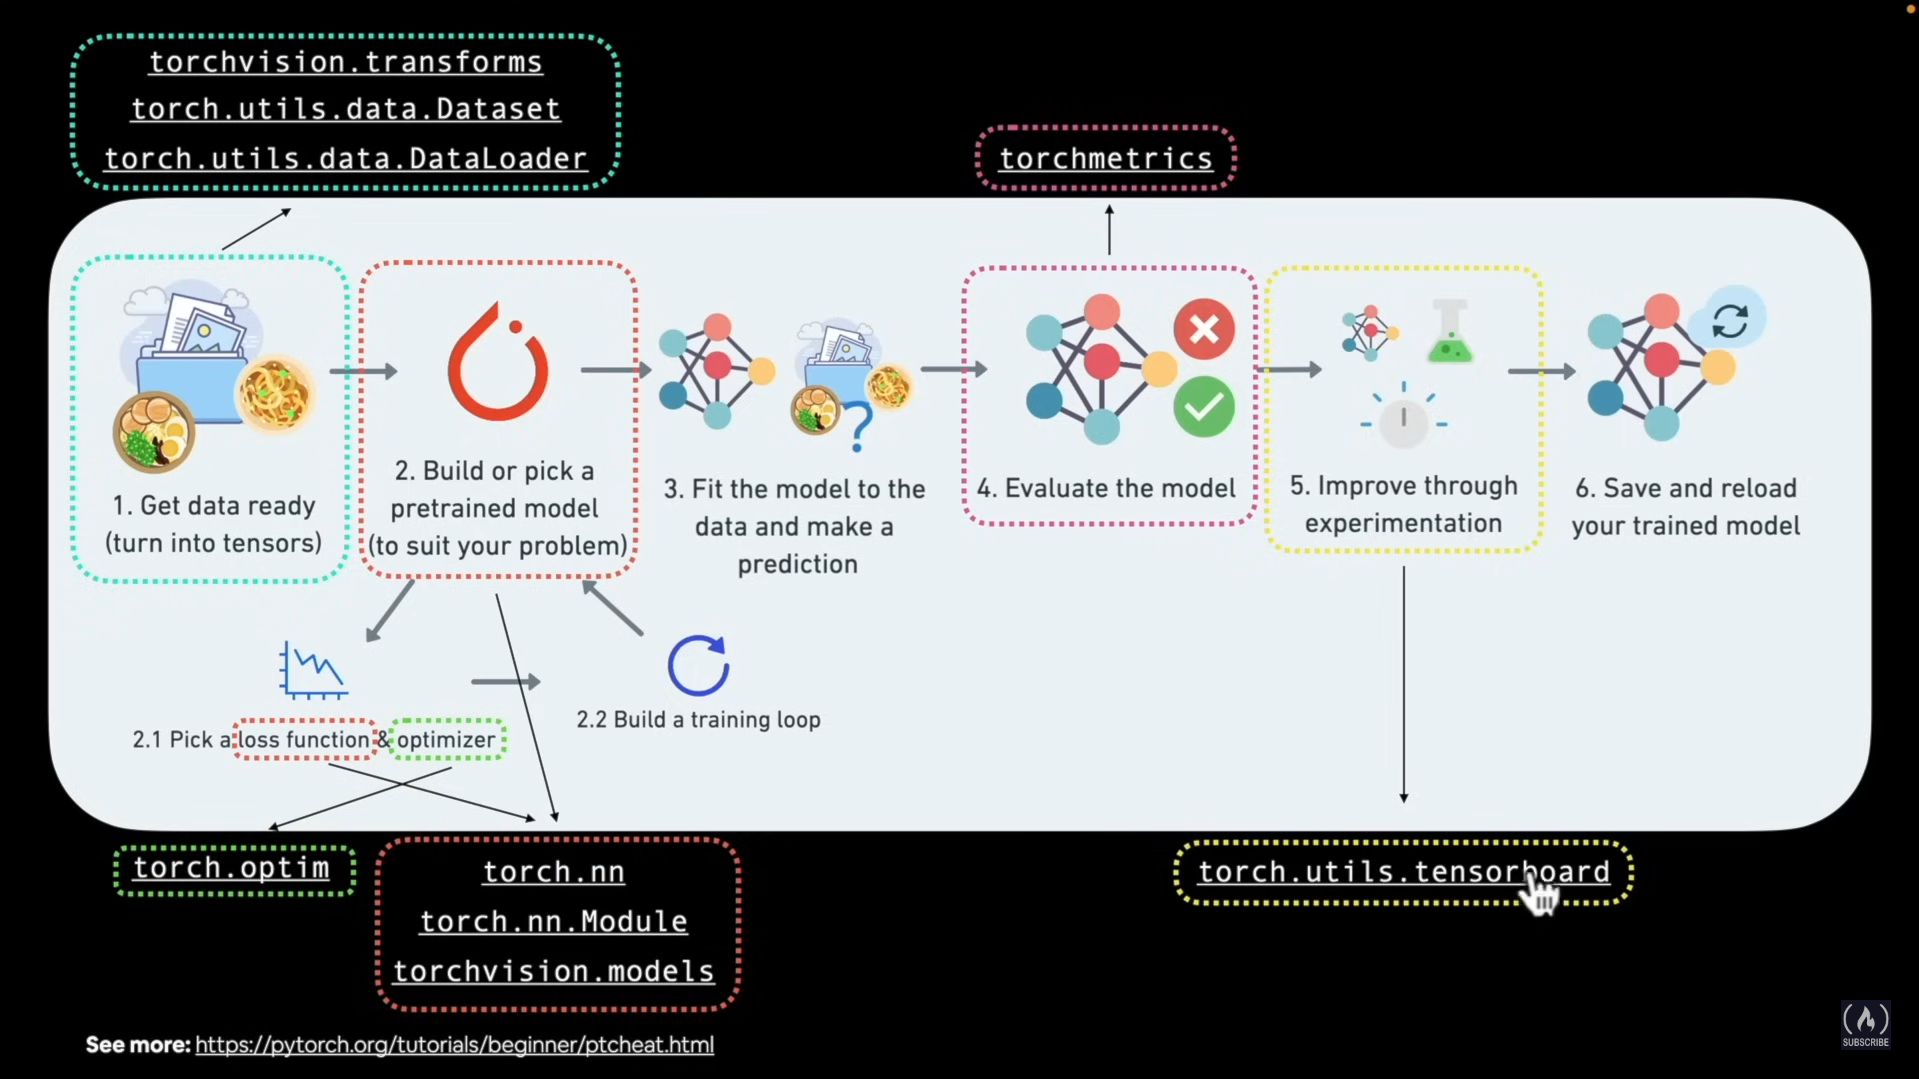

In [311]:
import torch
from torch import nn  # nn contains all the pytorche's building block
import matplotlib.pyplot as plt

In [312]:
torch.__version__

'2.6.0+cu124'

###Basic ML/DL Work flow
#### Data(any form) -> Numberical formate -> Learn pattern -> Representaion of output

#####  Goanna use linear regression formula to make straight line with known PARAMETER

Y = a + bX

b --> weight |
a --> bias

In [313]:
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02
X = torch.arange(start,end,step).unsqueeze(dim=1)
y = weight * X + bias

print(X[:10])
print(y[:10])
print(X.shape, y.shape)
print(len(X), len(y))

tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800]])
tensor([[0.3000],
        [0.3140],
        [0.3280],
        [0.3420],
        [0.3560],
        [0.3700],
        [0.3840],
        [0.3980],
        [0.4120],
        [0.4260]])
torch.Size([50, 1]) torch.Size([50, 1])
50 50


Spltting data into training and testing data

In [314]:
# train/test split

train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]   # 80% of data
X_test, y_test = X[train_split:], y[train_split:]     # 20% of data
# we can use skit learns train test split method , it taks ransomnes in splititng the data

print("Train split of X,Y:  ",len(X_train), len(y_train), "\nTest split of X,Y:  ", len(X_test), len(y_test))

Train split of X,Y:   40 40 
Test split of X,Y:   10 10


To understand the better we need to always VISUALIZE IT !!!

In [315]:
def plot_predictions(train_data=X_train,
                      train_labels=y_train,
                      test_data=X_test,
                      test_labels=y_test,
                      predictions=None):
  """
  plots training data , teat data and compares predictions.
  """
  plt.figure(figsize=(10,3))
  # plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

  #ploting test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  #Are there predictions , plot if the exist
  if predictions is not None:
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  plt.legend(prop={"size":10}) #show legends
  plt.show()

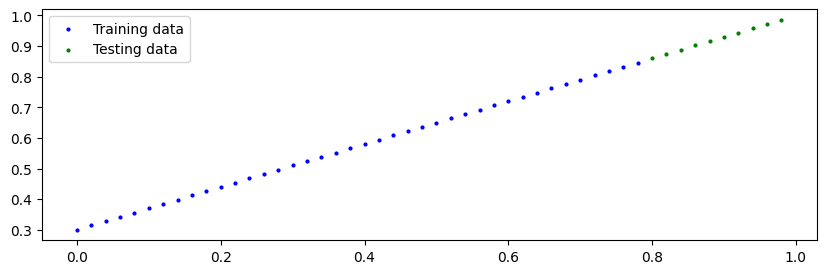

In [316]:
plot_predictions()


#### Building Model    ofr linear reg


In [317]:
from torch import nn

class LinearRegressionModel(nn.Module): # everything in pytorch inherits from nn.Modules
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,
                                                dtype=torch.float),
                                                requires_grad=True)

        self.bias = nn.Parameter(torch.randn(1,
                                            dtype=torch.float),
                                            requires_grad=True)

    # Forward method to define the computaion in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor:    #    x <--  is the inpur data (training data)
        return self.weights * x + self.bias            # Linear Regression data..

### Pytorch model bulding essentials
 * -> torch.nn - contains all building graph of computational graph(neural network)
 * -> torch.nn.Parameter -  what paramanets that our models try and learn
 * -> torch.nn.Module - base class for all neural network module , if you sub class it you should overwrite forward()
 * -> torch.optim - optimizer , help with gradient descent
 * -> forward() - All nn subclass require to overwrite this method as it defines what happens in the forward computation

In [318]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionModel()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [319]:
# Liat the named paramaters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [320]:
weight, bias  #  (0.7,0.3)

#  OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])
#  wanna make this    `weights`: closer -> 0.7       `bias`:closer -> 0.3

(0.7, 0.3)

### torch.infrence_mode()

To check the predictivesness, lets see how it predicts y_test based on x_test.

when we pass data through out mode. it is goint to run through forward()

In [321]:
X_test, y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [322]:
with torch.inference_mode():    #  infrence_mode disables the grad function
  y_preds = model_0(X_test)

# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

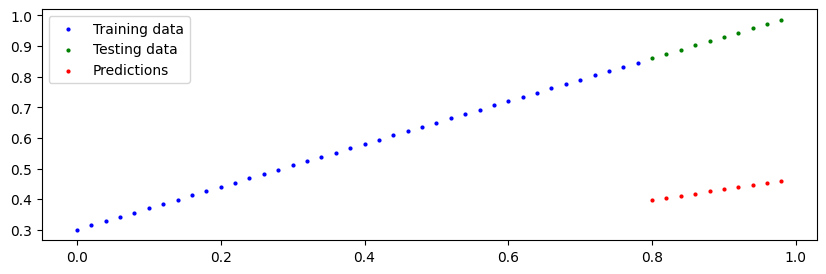

In [323]:
plot_predictions(predictions=y_preds)

#3. Training the model

So basically the idea of training the model is to move some unknown paramaters to some known paramaters... or poor representaion of data to better representaion.

one way to measure how poor/wrong the predictions are is to use a **LOSS FUNCTION**

loss function / cost function / criterion in different areas

#### Things we need to train
* loss function  -> wrongness
* optimizer      -> takes the loss of model and adjust models performance


On **pytorch** we spcifically need
* a training loop
* a testing loop

In [324]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [325]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [326]:
# set up a loss function
loss_fn = nn.L1Loss()

In [327]:
# set up an optimizer
optimizer = torch.optim.SGD(params = model_0.parameters(), lr = 0.01)
              # params -> model paramater that we wanna optmize
              # lr -> possibly high important hyperparamater , it defnes how big the optimizer changes the parameters

## Building a traing loop and testing loop

0. Loop through the data
1. Forward pass  -> use `forward()` to make predictions on data
2. Calculate the loss -> compare forward pass predictions to ground truth labels
3. Optimize zero grad
4. Loss backward -> moves backwards through the network to calculate the gradients of the parameters of our model with respect to loss (**backpropagation**)
5. Optimizer step -> use the otimizer adjust the paramaters to try and improve the loss (**gradient descent**)

In [328]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [329]:
epochs = 150
epoch_count = []
loss_values = []
test_loss_values = []
# epochs is the one loop through the data... (it is a hype parameter because we set it ourself)

## Training
# 0. Loop through the data
for epoch in range(epochs):
  # set teh model to training mode
  model_0.train() # sets all the parameters that requires gradient to required gradient

  #1. Forward pass
  y_pred =  model_0(X_train)

  #2. Calculating the loss
  loss = loss_fn(y_pred, y_train)

  #3. Optimizer zero grad
  optimizer.zero_grad()

  #4. Performs back propagation on the loss with respect to the paramaters og the model
  loss.backward()

  #5. Step the optimizer (perform gradient descent)
  optimizer.step()


  ## Testing...
  model_0.eval () # turns off gradient tracking and other setting which are not needed for evaluation/testing

  with torch.inference_mode():

    # 1. Do the ofrward pass
    test_pred = model_0(X_test)

    # 2. Calculate the loss
    test_loss = loss_fn(test_pred, y_test)

  print(f"")
  print(f"epoch {epoch+1}/{epochs}")
  print(f"loss: {loss} | test loss: {test_loss} | weight: {model_0.state_dict()['weights']} | bias: {model_0.state_dict()['bias']}")

  epoch_count.append(epoch+1)
  loss_values.append(loss)
  test_loss_values.append(test_loss)



epoch 1/150
loss: 0.31288138031959534 | test loss: 0.48106518387794495 | weight: tensor([0.3406]) | bias: tensor([0.1388])

epoch 2/150
loss: 0.3013603389263153 | test loss: 0.4675942063331604 | weight: tensor([0.3445]) | bias: tensor([0.1488])

epoch 3/150
loss: 0.28983935713768005 | test loss: 0.4541231691837311 | weight: tensor([0.3484]) | bias: tensor([0.1588])

epoch 4/150
loss: 0.2783183455467224 | test loss: 0.44065219163894653 | weight: tensor([0.3523]) | bias: tensor([0.1688])

epoch 5/150
loss: 0.26679736375808716 | test loss: 0.4271811842918396 | weight: tensor([0.3562]) | bias: tensor([0.1788])

epoch 6/150
loss: 0.2552763521671295 | test loss: 0.41371020674705505 | weight: tensor([0.3601]) | bias: tensor([0.1888])

epoch 7/150
loss: 0.24375534057617188 | test loss: 0.40023916959762573 | weight: tensor([0.3640]) | bias: tensor([0.1988])

epoch 8/150
loss: 0.23223432898521423 | test loss: 0.3867681920528412 | weight: tensor([0.3679]) | bias: tensor([0.2088])

epoch 9/150
lo

In [330]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6638])), ('bias', tensor([0.3153]))])

Previously: OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [331]:
loss_values[0]

import numpy as np
np.array(torch.tensor(loss_values).cpu().numpy())

array([0.31288138, 0.30136034, 0.28983936, 0.27831835, 0.26679736,
       0.25527635, 0.24375534, 0.23223433, 0.22071333, 0.20919232,
       0.19767132, 0.18615034, 0.17462933, 0.16310832, 0.15158734,
       0.14006636, 0.12854536, 0.11702438, 0.10609122, 0.09681284,
       0.08908726, 0.08227583, 0.07638873, 0.07160007, 0.06747635,
       0.06395438, 0.06097005, 0.05845819, 0.05635259, 0.05458578,
       0.05314853, 0.05181945, 0.05069301, 0.04982285, 0.04895269,
       0.04819351, 0.04753182, 0.04692793, 0.04642332, 0.04591871,
       0.04543797, 0.04503796, 0.04463796, 0.04423796, 0.04383796,
       0.04343796, 0.04307463, 0.04272563, 0.04237663, 0.04202763,
       0.04167863, 0.04132963, 0.04098063, 0.04063163, 0.04028264,
       0.03993364, 0.03958464, 0.03923564, 0.03888664, 0.03853764,
       0.03818933, 0.03785244, 0.03750344, 0.03716412, 0.03681822,
       0.03647511, 0.03613304, 0.0357861 , 0.03544784, 0.03509884,
       0.0347609 , 0.03441364, 0.03407188, 0.03372844, 0.03338

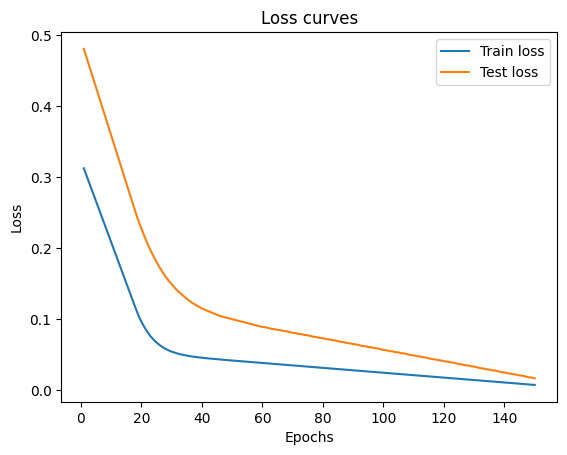

In [332]:
## plot the loss curves

np_loss = np.array(torch.tensor(loss_values).cpu().numpy())
np_test_loss = np.array(torch.tensor(test_loss_values).cpu().numpy())


plt.plot(epoch_count, np_loss, label="Train loss")
plt.plot(epoch_count, np_test_loss, label="Test loss")
plt.title("Loss curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

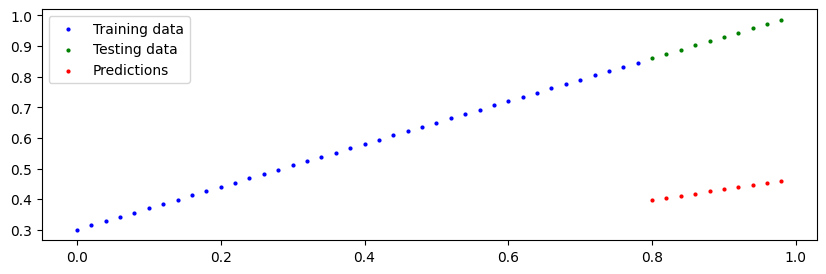

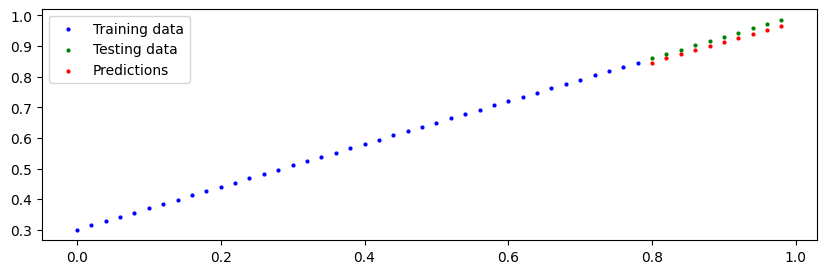

In [333]:
with torch.inference_mode():
  y_preds_new = model_0(X_test)

plot_predictions(predictions=y_preds)
plot_predictions(predictions=y_preds_new)

### Saving a model in pytorch

saving & loading :-  
* torch.save() - save the model in pickle formate
* torch.load() - load a saved object
* torch.nn.Module.load_state_dict() - load a models saved state dictionary

In [336]:
# saving our model

from pathlib import Path

# Creating model directory
MPDEL_PATH = Path("models")
MPDEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "01_pytorch_workflow_model.pth"
MODEL_SAVE_PATH = MPDEL_PATH / MODEL_NAME

print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj = model_0.state_dict(), f = MODEL_SAVE_PATH)

Saving model to: models/01_pytorch_workflow_model.pth


In [338]:
!ls -l models

total 4
-rw-r--r-- 1 root root 1668 Jun  1 09:40 01_pytorch_workflow_model.pth


In [342]:
## loading the model

loaded_model = torch.load(MODEL_SAVE_PATH)

In [343]:
loaded_model

OrderedDict([('weights', tensor([0.6638])), ('bias', tensor([0.3153]))])

In [344]:
model_0

LinearRegressionModel()

In [346]:
# Instantiate a new instance of our model (this will be instantiated with random weights)
loaded_model_0 = LinearRegressionModel()

# Load the state_dict of our saved model (this will update the new instance of our model with trained weights)
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [347]:
# 1. Put the loaded model into evaluation mode
loaded_model_0.eval()

# 2. Use the inference mode context manager to make predictions
with torch.inference_mode():
    loaded_model_preds = loaded_model_0(X_test) # perform a forward pass on the test data with the loaded model

In [349]:
model_0.eval()

with torch.inference_mode():
    model_preds = model_0(X_test)

In [350]:
# Compare previous model predictions with loaded model predictions (these should be the same)
loaded_model_preds == model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

## Putting it all together